In [2]:
!pip install requests beautifulsoup4 pandas lxml tqdm Sastrawi scikit-learn nltk matplotlib

  Using cached Sastrawi-1.0.1-py2.py3-none-any.whl (209 kB)
     ---------------------------------------- 8.3/8.3 MB 81.5 kB/s eta 0:00:00
     ---------------------------------------- 1.8/1.8 MB 74.1 kB/s eta 0:00:00
     ---------------------------------------- 9.3/9.3 MB 70.9 kB/s eta 0:00:00
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
     ------------------------------------- 306.1/306.1 kB 93.8 kB/s eta 0:00:00
     ------------------------------------- 474.0/474.0 kB 58.2 kB/s eta 0:00:00
     ------------------------------------- 125.3/125.3 kB 34.6 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ---------------------------------------- 2.5/2.5 MB 66.4 kB/s eta 0:00:00
     --------------------------------------- 70.7/70.7 kB 84.2 kB/s eta 0:00:00
     ---------------------------------------- 7.2/7.2 MB 75.0 kB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\PPW\\env_webmining\\Lib\\site-packages\\pyparsing\\__init__.py'
Check the permissions.


[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached Sastrawi-1.0.1-py2.py3-none-any.whl (209 kB)
  Using cached scikit_learn-1.9.1-cp311-cp311-win_amd64.whl (8.3 MB)
  Using cached nltk-3.10.3-py3-none-any.whl (1.8 MB)
     ---------------------------------------- 9.3/9.3 MB 69.9 kB/s eta 0:00:00
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
  Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)
  Using cached click-8.5.0-py3-none-any.whl (125 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached fonttools-4.65.0-cp311-cp311-win_amd64.whl (2.5 MB)
  Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl (70 kB)
     ---------------------------------------- 7.2/7.2 MB 92.9 kB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from tqdm import tqdm
import time
import re
import nltk
import matplotlib.pyplot as plt

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

In [3]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\Assatya
[nltk_data]     Dewantara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
urls = [
    # Finance
    "https://finance.detik.com/fintech",
    "https://finance.detik.com/infrastruktur",

    # Sport
    "https://sport.detik.com/sepakbola/liga-inggris",
    "https://sport.detik.com/sepakbola/liga-italia"
]

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/139.0.0.0 Safari/537.36"
}

for url in urls:
    response = requests.get(url, headers=headers, timeout=10)

    print("URL:", url)
    print("Status Code:", response.status_code)
    print("Panjang halaman:", len(response.text))
    print("-" * 50)

URL: https://finance.detik.com/fintech
Status Code: 200
Panjang halaman: 317484
--------------------------------------------------
URL: https://finance.detik.com/infrastruktur
Status Code: 200
Panjang halaman: 322089
--------------------------------------------------
URL: https://sport.detik.com/sepakbola/liga-inggris
Status Code: 200
Panjang halaman: 269498
--------------------------------------------------
URL: https://sport.detik.com/sepakbola/liga-italia
Status Code: 200
Panjang halaman: 272748
--------------------------------------------------


In [5]:
for url in urls:
    response = requests.get(url, headers=headers, timeout=10)
    
    soup = BeautifulSoup(response.text, "html.parser")
    
    print("URL:", url)
    
    if soup.title:
        print("Judul halaman:", soup.title.get_text(strip=True))
    else:
        print("Judul halaman: Tidak ditemukan")
    
    print("Status Code:", response.status_code)
    print("-" * 50)

URL: https://finance.detik.com/fintech
Judul halaman: Info Berita Terkini Fintech, Startup, Bitcoin
Status Code: 200
--------------------------------------------------
URL: https://finance.detik.com/infrastruktur
Judul halaman: detikFinance - Berita Ekonomi Bisnis, dan Investasi Hari Ini
Status Code: 200
--------------------------------------------------
URL: https://sport.detik.com/sepakbola/liga-inggris
Judul halaman: Informasi Berita Seputar Sepakbola Liga Inggris Terlengkap
Status Code: 200
--------------------------------------------------
URL: https://sport.detik.com/sepakbola/liga-italia
Judul halaman: Informasi Berita Seputar Sepakbola Liga Italia Terlengkap
Status Code: 200
--------------------------------------------------


In [6]:
data_link = []

for url in urls:
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.text, "html.parser")
    
    links = soup.find_all("a", href=True)

    for link in links:
        href = link["href"]
        text = link.get_text(" ", strip=True)

        # Finance - Fintech
        if "/fintech/" in href and "/d-" in href and text:
            kategori = "Fintech"

        # Finance - Infrastruktur
        elif "/infrastruktur/" in href and "/d-" in href and text:
            kategori = "Infrastruktur"

        # Sport - Liga Inggris
        elif "/sepakbola/liga-inggris/" in href and "/d-" in href and text:
            kategori = "Liga Inggris"

        # Sport - Liga Italia
        elif "/sepakbola/liga-italia/" in href and "/d-" in href and text:
            kategori = "Liga Italia"

        else:
            continue

        data_link.append({
            "judul": text,
            "url": href,
            "kategori": kategori
        })

    print("Selesai crawling:", url)

df_link = pd.DataFrame(data_link)

# Hilangkan URL duplikat
df_link = df_link.drop_duplicates(subset="url")

# Reset index
df_link = df_link.reset_index(drop=True)

print("Total artikel:", len(df_link))

# Tampilkan jumlah artikel setiap kategori
print("\nJumlah per kategori:")
print(df_link["kategori"].value_counts())

df_link.head(10)

Selesai crawling: https://finance.detik.com/fintech
Selesai crawling: https://finance.detik.com/infrastruktur
Selesai crawling: https://sport.detik.com/sepakbola/liga-inggris
Selesai crawling: https://sport.detik.com/sepakbola/liga-italia
Total artikel: 207

Jumlah per kategori:
kategori
Liga Inggris     53
Liga Italia      52
Fintech          51
Infrastruktur    51
Name: count, dtype: int64


,judul,url,kategori
0,"Bitcoin Tembus US$ 87.000, Ini Sederet Pemicunya",https://finance.detik.com/fintech/d-8674812/bi...,Fintech
1,"Harga Bitcoin Terbang ke Rp 1,53 M, Tertinggi ...",https://finance.detik.com/fintech/d-8673320/ha...,Fintech
2,Bitcoin Melesat Usai Pengumuman Suku Bunga AS,https://finance.detik.com/fintech/d-8667716/bi...,Fintech
3,"Investor Muda Dominasi Pasar Modal, Ajaib Kena...",https://finance.detik.com/fintech/d-8673492/in...,Fintech
4,"Harga Bitcoin Naik Jadi 1,35 Miliar Usai The F...",https://finance.detik.com/fintech/d-8666685/ha...,Fintech
5,"Bitcoin Masih Diminati Investor, Ini Tandanya",https://finance.detik.com/fintech/d-8655330/bi...,Fintech
6,Nilai Transaksi Aset Kripto RI Turun 28% Jadi ...,https://finance.detik.com/fintech/d-8652464/ni...,Fintech
7,Keuntungan Gadai BPKB Motor Saat Kebutuhan Dan...,https://finance.detik.com/fintech/d-8646895/ke...,Fintech
8,6 Cara Memilih Aplikasi Pinjaman Online Bunga ...,https://finance.detik.com/fintech/d-8644968/6-...,Fintech
9,"Bitcoin Terbang ke Level US$ 80.000, Ini Penye...",https://finance.detik.com/fintech/d-8637573/bi...,Fintech


In [7]:
print("Jumlah link:", len(df_link))

Jumlah link: 207


In [8]:
df_link

,judul,url,kategori
0,"Bitcoin Tembus US$ 87.000, Ini Sederet Pemicunya",https://finance.detik.com/fintech/d-8674812/bi...,Fintech
1,"Harga Bitcoin Terbang ke Rp 1,53 M, Tertinggi ...",https://finance.detik.com/fintech/d-8673320/ha...,Fintech
2,Bitcoin Melesat Usai Pengumuman Suku Bunga AS,https://finance.detik.com/fintech/d-8667716/bi...,Fintech
3,"Investor Muda Dominasi Pasar Modal, Ajaib Kena...",https://finance.detik.com/fintech/d-8673492/in...,Fintech
4,"Harga Bitcoin Naik Jadi 1,35 Miliar Usai The F...",https://finance.detik.com/fintech/d-8666685/ha...,Fintech
...,...,...,...
202,Klasemen Liga Italia: Juventus Kian Melorot,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
203,Sassuolo Vs Juventus: Jay Idzes dkk Menang Dra...,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
204,Badai Cedera Juventus Bukan Jadi Alasan untuk ...,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
205,Lazio Vs Milan: Dua Wajah Rossoneri,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia


In [9]:
df_artikel = df_link[
    (
        df_link["url"].str.contains("/fintech/", na=False)
        |
        df_link["url"].str.contains("/infrastruktur/", na=False)
        |
        df_link["url"].str.contains("/sepakbola/liga-inggris/", na=False)
        |
        df_link["url"].str.contains("/sepakbola/liga-italia/", na=False)
    )
    &
    df_link["url"].str.contains("/d-", na=False)
].copy()

# Hilangkan URL duplikat
df_artikel = df_artikel.drop_duplicates(subset="url")

# Reset index
df_artikel = df_artikel.reset_index(drop=True)

print("Jumlah seluruh artikel:", len(df_artikel))

print("\nJumlah artikel per kategori:")
print(df_artikel["kategori"].value_counts())

Jumlah seluruh artikel: 207

Jumlah artikel per kategori:
kategori
Liga Inggris     53
Liga Italia      52
Fintech          51
Infrastruktur    51
Name: count, dtype: int64


In [10]:
df_artikel.head(10)

,judul,url,kategori
0,"Bitcoin Tembus US$ 87.000, Ini Sederet Pemicunya",https://finance.detik.com/fintech/d-8674812/bi...,Fintech
1,"Harga Bitcoin Terbang ke Rp 1,53 M, Tertinggi ...",https://finance.detik.com/fintech/d-8673320/ha...,Fintech
2,Bitcoin Melesat Usai Pengumuman Suku Bunga AS,https://finance.detik.com/fintech/d-8667716/bi...,Fintech
3,"Investor Muda Dominasi Pasar Modal, Ajaib Kena...",https://finance.detik.com/fintech/d-8673492/in...,Fintech
4,"Harga Bitcoin Naik Jadi 1,35 Miliar Usai The F...",https://finance.detik.com/fintech/d-8666685/ha...,Fintech
5,"Bitcoin Masih Diminati Investor, Ini Tandanya",https://finance.detik.com/fintech/d-8655330/bi...,Fintech
6,Nilai Transaksi Aset Kripto RI Turun 28% Jadi ...,https://finance.detik.com/fintech/d-8652464/ni...,Fintech
7,Keuntungan Gadai BPKB Motor Saat Kebutuhan Dan...,https://finance.detik.com/fintech/d-8646895/ke...,Fintech
8,6 Cara Memilih Aplikasi Pinjaman Online Bunga ...,https://finance.detik.com/fintech/d-8644968/6-...,Fintech
9,"Bitcoin Terbang ke Level US$ 80.000, Ini Penye...",https://finance.detik.com/fintech/d-8637573/bi...,Fintech


In [11]:
# Gunakan seluruh artikel dari 4 sumber
df_artikel = df_artikel.copy()

print("Jumlah artikel yang akan di-crawl:", len(df_artikel))

print("\nJumlah per kategori:")
print(df_artikel["kategori"].value_counts())

Jumlah artikel yang akan di-crawl: 207

Jumlah per kategori:
kategori
Liga Inggris     53
Liga Italia      52
Fintech          51
Infrastruktur    51
Name: count, dtype: int64


In [12]:
df_artikel.tail()

,judul,url,kategori
202,Klasemen Liga Italia: Juventus Kian Melorot,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
203,Sassuolo Vs Juventus: Jay Idzes dkk Menang Dra...,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
204,Badai Cedera Juventus Bukan Jadi Alasan untuk ...,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
205,Lazio Vs Milan: Dua Wajah Rossoneri,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
206,"Lazio Vs Milan: Moreira 2 Gol, Rossoneri Paksa...",https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia


In [18]:
hasil_scraping = []

for i, row in tqdm(df_artikel.iterrows(), total=len(df_artikel)):
    url = row["url"]

    try:
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.text, "html.parser")

        # =========================
        # TENTUKAN KATEGORI
        # =========================
        if "finance.detik.com" in url:
            kategori = "Finance"
        elif "sport.detik.com" in url:
            kategori = "Sport"
        else:
            kategori = "Lainnya"

        # =========================
        # AMBIL JUDUL
        # =========================
        judul_tag = soup.find("h1")

        if judul_tag:
            judul = judul_tag.get_text(" ", strip=True)
        else:
            judul = row.get("judul", "")

        # =========================
        # AMBIL ISI ARTIKEL
        # =========================
        artikel = soup.find("div", class_="detail__body-text")

        # Jika tidak ditemukan, coba class lain
        if not artikel:
            artikel = soup.find("div", class_="detail__body")

        if not artikel:
            artikel = soup.find("article")

        if artikel:
            # Hapus elemen yang bukan isi artikel
            for tag in artikel.find_all(
                ["script", "style", "iframe", "button", "form"]
            ):
                tag.decompose()

            isi = artikel.get_text(" ", strip=True)
        else:
            isi = ""

        # =========================
        # SIMPAN HASIL
        # =========================
        if isi:
            hasil_scraping.append({
                "kategori": kategori,
                "judul": judul,
                "url": url,
                "isi": isi
            })

        time.sleep(1)

    except Exception as e:
        print(f"Gagal scraping: {url}")
        print("Error:", e)

# =========================
# BUAT DATAFRAME
# =========================
df_scraping = pd.DataFrame(hasil_scraping)

print("Jumlah artikel berhasil:", len(df_scraping))

# Cek jumlah masing-masing kategori
print("\nJumlah berdasarkan kategori:")
print(df_scraping["kategori"].value_counts())

# Tampilkan 5 data pertama
display(df_scraping.head())

  5%|▍         | 10/207 [00:35<17:53,  5.45s/it]

Gagal scraping: https://finance.detik.com/fintech/d-8637573/bitcoin-terbang-ke-level-us-80-000-ini-penyebabnya
Error: HTTPSConnectionPool(host='finance.detik.com', port=443): Read timed out. (read timeout=10)


  5%|▌         | 11/207 [00:50<27:30,  8.42s/it]

Gagal scraping: https://finance.detik.com/fintech/d-8636465/mendag-ungkap-cara-ri-bentuk-bursa-mineral-tiru-pola-bursa-kripto
Error: HTTPSConnectionPool(host='finance.detik.com', port=443): Read timed out.


100%|██████████| 207/207 [10:34<00:00,  3.06s/it]

Jumlah artikel berhasil: 205

Jumlah berdasarkan kategori:
kategori
Sport      105
Finance    100
Name: count, dtype: int64


,kategori,judul,url,isi
0,Finance,"Bitcoin Tembus US$ 87.000, Ini Sederet Pemicunya",https://finance.detik.com/fintech/d-8674812/bi...,Jakarta - Harga Bitcoin (BTC) sempat menembus ...
1,Finance,"Harga Bitcoin Terbang ke Rp 1,53 M, Tertinggi ...",https://finance.detik.com/fintech/d-8673320/ha...,Jakarta - Harga Bitcoin naik menembus level US...
2,Finance,Bitcoin Melesat Usai Pengumuman Suku Bunga AS,https://finance.detik.com/fintech/d-8667716/bi...,Jakarta - Harga Bitcoin (BTC) bergerak naik da...
3,Finance,"Investor Muda Dominasi Pasar Modal, Ajaib Kena...",https://finance.detik.com/fintech/d-8673492/in...,Jakarta - Ajaib memperkuat edukasi pasar modal...
4,Finance,"Harga Bitcoin Naik Jadi 1,35 Miliar Usai The F...",https://finance.detik.com/fintech/d-8666685/ha...,Jakarta - Harga Bitcoin menguat pada perdagang...


In [19]:
df_scraping.head()

,kategori,judul,url,isi
0,Finance,"Bitcoin Tembus US$ 87.000, Ini Sederet Pemicunya",https://finance.detik.com/fintech/d-8674812/bi...,Jakarta - Harga Bitcoin (BTC) sempat menembus ...
1,Finance,"Harga Bitcoin Terbang ke Rp 1,53 M, Tertinggi ...",https://finance.detik.com/fintech/d-8673320/ha...,Jakarta - Harga Bitcoin naik menembus level US...
2,Finance,Bitcoin Melesat Usai Pengumuman Suku Bunga AS,https://finance.detik.com/fintech/d-8667716/bi...,Jakarta - Harga Bitcoin (BTC) bergerak naik da...
3,Finance,"Investor Muda Dominasi Pasar Modal, Ajaib Kena...",https://finance.detik.com/fintech/d-8673492/in...,Jakarta - Ajaib memperkuat edukasi pasar modal...
4,Finance,"Harga Bitcoin Naik Jadi 1,35 Miliar Usai The F...",https://finance.detik.com/fintech/d-8666685/ha...,Jakarta - Harga Bitcoin menguat pada perdagang...


In [20]:
print(df_scraping.iloc[0]["isi"])

Jakarta - Harga Bitcoin (BTC) sempat menembus level tertinggi di US$ 87.000 pada perdagangan awal pekan. Penguatan ini didorong oleh sentimen pasar yang positif secara bersamaan. Chief Marketing Officer INDODAX, Aloysia Dian, menilai penguatan Bitcoin kali ini didorong oleh beberapa faktor yang datang secara bersamaan, mulai dari masuknya dana institusional, membaiknya sentimen pasar, hingga perkembangan regulasi aset digital di Amerika Serikat. Data CoinMarketCap menunjukkan Bitcoin berhasil menembus angka US$87.200, sebelum bergerak kembali di kisaran US$ 85.000-US$ 86.000 pada Selasa (22/9). SCROLL TO CONTINUE WITH CONTENT "Pergerakan Bitcoin kali ini tidak hanya didorong oleh satu faktor. Minat investor institusional kembali menguat, serta sentimen terhadap aset digital juga membaik. Selain itu, perkembangan regulasi di Amerika Serikat turut memperbaiki sentimen terhadap ekosistem aset digital secara lebih luas dan turut mendorong harga Bitcoin," ujar Aloysia dalam keterangan tertu

In [21]:
print("Isi kosong:", (df_scraping["isi"] == "").sum())

Isi kosong: 0


In [22]:
print("Jumlah data:", len(df_scraping))
print("Kolom:", df_scraping.columns.tolist())

df_scraping.info()

Jumlah data: 205
Kolom: ['kategori', 'judul', 'url', 'isi']
<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   kategori  205 non-null    str  
 1   judul     205 non-null    str  
 2   url       205 non-null    str  
 3   isi       205 non-null    str  
dtypes: str(4)
memory usage: 6.5 KB


In [23]:
# =========================
# CEK 1 ARTIKEL
# =========================

data = df_scraping.iloc[0]

print("=" * 60)
print("CONTOH HASIL SCRAPING")
print("=" * 60)

print("\nKATEGORI:")
print(data["kategori"])

print("\nJUDUL:")
print(data["judul"])

print("\nURL:")
print(data["url"])

print("\nISI ARTIKEL:")
print(data["isi"])

print("\n" + "=" * 60)

CONTOH HASIL SCRAPING

KATEGORI:
Finance

JUDUL:
Bitcoin Tembus US$ 87.000, Ini Sederet Pemicunya

URL:
https://finance.detik.com/fintech/d-8674812/bitcoin-tembus-us-87-000-ini-sederet-pemicunya

ISI ARTIKEL:
Jakarta - Harga Bitcoin (BTC) sempat menembus level tertinggi di US$ 87.000 pada perdagangan awal pekan. Penguatan ini didorong oleh sentimen pasar yang positif secara bersamaan. Chief Marketing Officer INDODAX, Aloysia Dian, menilai penguatan Bitcoin kali ini didorong oleh beberapa faktor yang datang secara bersamaan, mulai dari masuknya dana institusional, membaiknya sentimen pasar, hingga perkembangan regulasi aset digital di Amerika Serikat. Data CoinMarketCap menunjukkan Bitcoin berhasil menembus angka US$87.200, sebelum bergerak kembali di kisaran US$ 85.000-US$ 86.000 pada Selasa (22/9). SCROLL TO CONTINUE WITH CONTENT "Pergerakan Bitcoin kali ini tidak hanya didorong oleh satu faktor. Minat investor institusional kembali menguat, serta sentimen terhadap aset digital juga m

In [24]:
# Simpan hasil scraping Finance + Sport
df_scraping.to_csv(
    "hasil_scraping_detik.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Data berhasil disimpan sebagai hasil_scraping_detik.csv")

Data berhasil disimpan sebagai hasil_scraping_detik.csv


In [25]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_words = set(
    stopwords.words("indonesian")
)

print("Jumlah stopword:", len(stop_words))

Jumlah stopword: 757


In [26]:
def preprocessing_teks(teks):
    # Pastikan teks berupa string
    teks = str(teks)

    # Case folding
    teks = teks.lower()

    # Menghapus URL
    teks = re.sub(
        r"http\S+|www\S+",
        " ",
        teks
    )

    # Menghapus angka
    teks = re.sub(
        r"\d+",
        " ",
        teks
    )

    # Menghapus karakter selain huruf
    teks = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        teks
    )

    # Menghapus spasi berlebih
    teks = re.sub(
        r"\s+",
        " ",
        teks
    ).strip()

    # Tokenisasi sederhana
    tokens = teks.split()

    # Stopword removal
    tokens = [
        kata
        for kata in tokens
        if kata not in stop_words
    ]

    # Menggabungkan token
    teks = " ".join(tokens)

    # Stemming Bahasa Indonesia
    teks = stemmer.stem(teks)

    return teks

In [27]:
df_scraping["teks_preprocessing"] = (
    df_scraping["isi"]
    .apply(preprocessing_teks)
)

In [28]:
df_scraping[
    [
        "kategori",
        "judul",
        "isi",
        "teks_preprocessing"
    ]
].head(3)

,kategori,judul,isi,teks_preprocessing
0,Finance,"Bitcoin Tembus US$ 87.000, Ini Sederet Pemicunya",Jakarta - Harga Bitcoin (BTC) sempat menembus ...,jakarta harga bitcoin btc tembus level tinggi ...
1,Finance,"Harga Bitcoin Terbang ke Rp 1,53 M, Tertinggi ...",Jakarta - Harga Bitcoin naik menembus level US...,jakarta harga bitcoin tembus level us rp milia...
2,Finance,Bitcoin Melesat Usai Pengumuman Suku Bunga AS,Jakarta - Harga Bitcoin (BTC) bergerak naik da...,jakarta harga bitcoin btc gerak kisar us rp mi...


In [29]:
print("SEBELUM:")
print(df_scraping.iloc[0]["isi"][:1000])

print("\nSETELAH PREPROCESSING:")
print(
    df_scraping.iloc[0]["teks_preprocessing"][:1000]
)

SEBELUM:
Jakarta - Harga Bitcoin (BTC) sempat menembus level tertinggi di US$ 87.000 pada perdagangan awal pekan. Penguatan ini didorong oleh sentimen pasar yang positif secara bersamaan. Chief Marketing Officer INDODAX, Aloysia Dian, menilai penguatan Bitcoin kali ini didorong oleh beberapa faktor yang datang secara bersamaan, mulai dari masuknya dana institusional, membaiknya sentimen pasar, hingga perkembangan regulasi aset digital di Amerika Serikat. Data CoinMarketCap menunjukkan Bitcoin berhasil menembus angka US$87.200, sebelum bergerak kembali di kisaran US$ 85.000-US$ 86.000 pada Selasa (22/9). SCROLL TO CONTINUE WITH CONTENT "Pergerakan Bitcoin kali ini tidak hanya didorong oleh satu faktor. Minat investor institusional kembali menguat, serta sentimen terhadap aset digital juga membaik. Selain itu, perkembangan regulasi di Amerika Serikat turut memperbaiki sentimen terhadap ekosistem aset digital secara lebih luas dan turut mendorong harga Bitcoin," ujar Aloysia dalam keteran

In [30]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(
    df_scraping["teks_preprocessing"]
)

In [31]:
kata_unik = vectorizer.get_feature_names_out()

print(
    "Jumlah seluruh kata unik:",
    len(kata_unik)
)

Jumlah seluruh kata unik: 4470


In [32]:
print(kata_unik[:100])

['aaplx' 'abadi' 'abai' 'abang' 'abankwah' 'abar' 'abdi' 'abdul' 'absen'
 'ac' 'academy' 'acara' 'accident' 'account' 'acd' 'ace' 'aceh' 'acl'
 'act' 'acu' 'ada' 'adakan' 'adams' 'adang' 'adaptasi' 'adaptif'
 'adaptive' 'adcp' 'adhi' 'adi' 'adil' 'admin' 'administrasi'
 'administratif' 'adopsi' 'adp' 'adr' 'adrianto' 'adrien' 'adu'
 'advertisement' 'advisory' 'adzic' 'aee' 'aff' 'affengruber' 'aftech'
 'against' 'agam' 'agency' 'agenda' 'ageng' 'agraria' 'agreement'
 'agresif' 'agresivitas' 'agun' 'agung' 'agus' 'agustus' 'ahi' 'ahli'
 'ahy' 'ai' 'air' 'aires' 'airnav' 'airport' 'aja' 'ajaib' 'ajak' 'ajang'
 'ajar' 'aji' 'aju' 'akademi' 'akal' 'akan' 'akanji' 'akd' 'akhir'
 'akibat' 'akn' 'akomodasi' 'akrab' 'akses' 'aksesibilitas' 'aksi' 'aktif'
 'aktivitas' 'aktual' 'aku' 'akuisisi' 'akun' 'akuntabel' 'akuntabilitas'
 'akurasi' 'akurat' 'alajbegovic' 'alam']


In [33]:
TfidfVectorizer()

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [34]:
print(
    "Ukuran matriks TF-IDF:",
    tfidf_matrix.shape
)

Ukuran matriks TF-IDF: (205, 4470)


In [35]:
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=kata_unik
)

df_tfidf.head()

,aaplx,abadi,abai,abang,abankwah,abar,abdi,abdul,absen,ac,...,zhegrova,zhergova,zidane,zielinski,zielinsky,zinedine,zion,zirkzee,zona,zubimendi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
tfidf_dense = tfidf_matrix.toarray()

pca = PCA(
    n_components=2
)

tfidf_pca = pca.fit_transform(
    tfidf_dense
)

print(
    "Ukuran sebelum PCA:",
    tfidf_dense.shape
)

print(
    "Ukuran setelah PCA:",
    tfidf_pca.shape
)

Ukuran sebelum PCA: (205, 4470)
Ukuran setelah PCA: (205, 2)


In [37]:
df_pca = pd.DataFrame(
    tfidf_pca,
    columns=["PC1", "PC2"]
)

df_pca["kategori"] = df_scraping["kategori"].values
df_pca["judul"] = df_scraping["judul"].values
df_pca["isi"] = df_scraping["isi"].values
df_pca["url"] = df_scraping["url"].values

df_pca.head(10)

,PC1,PC2,kategori,judul,isi,url
0,-0.402166,0.225303,Finance,"Bitcoin Tembus US$ 87.000, Ini Sederet Pemicunya",Jakarta - Harga Bitcoin (BTC) sempat menembus ...,https://finance.detik.com/fintech/d-8674812/bi...
1,-0.322350,0.182252,Finance,"Harga Bitcoin Terbang ke Rp 1,53 M, Tertinggi ...",Jakarta - Harga Bitcoin naik menembus level US...,https://finance.detik.com/fintech/d-8673320/ha...
2,-0.404813,0.213236,Finance,Bitcoin Melesat Usai Pengumuman Suku Bunga AS,Jakarta - Harga Bitcoin (BTC) bergerak naik da...,https://finance.detik.com/fintech/d-8667716/bi...
3,-0.174724,0.048724,Finance,"Investor Muda Dominasi Pasar Modal, Ajaib Kena...",Jakarta - Ajaib memperkuat edukasi pasar modal...,https://finance.detik.com/fintech/d-8673492/in...
4,-0.263174,0.119274,Finance,"Harga Bitcoin Naik Jadi 1,35 Miliar Usai The F...",Jakarta - Harga Bitcoin menguat pada perdagang...,https://finance.detik.com/fintech/d-8666685/ha...
5,-0.293418,0.153119,Finance,"Bitcoin Masih Diminati Investor, Ini Tandanya",Jakarta - ETF Bitcoin spot di Amerika Serikat ...,https://finance.detik.com/fintech/d-8655330/bi...
6,-0.363007,0.166213,Finance,Nilai Transaksi Aset Kripto RI Turun 28% Jadi ...,Jakarta - Otoritas Jasa Keuangan (OJK) melapor...,https://finance.detik.com/fintech/d-8652464/ni...
7,-0.096656,-0.009972,Finance,Keuntungan Gadai BPKB Motor Saat Kebutuhan Dan...,Jakarta - Kehidupan sering kali tak selalu ber...,https://finance.detik.com/fintech/d-8646895/ke...
8,-0.140118,0.002632,Finance,6 Cara Memilih Aplikasi Pinjaman Online Bunga ...,"Jakarta - Saat membutuhkan dana mendesak, memi...",https://finance.detik.com/fintech/d-8644968/6-...
9,-0.390348,0.178499,Finance,"Transaksi Kripto RI Tembus Rp 20,52 T",Jakarta - Otoritas Jasa Keuangan (OJK) mencata...,https://finance.detik.com/fintech/d-8636301/tr...


In [38]:
# =========================
# EXPLAINED VARIANCE PCA
# =========================

variance_ratio = pca.explained_variance_ratio_
total_variance = variance_ratio.sum()

print("=" * 50)
print("HASIL PCA")
print("=" * 50)

print(f"PC1 : {variance_ratio[0]:.4f} "
      f"({variance_ratio[0] * 100:.2f}%)")

print(f"PC2 : {variance_ratio[1]:.4f} "
      f"({variance_ratio[1] * 100:.2f}%)")

print("-" * 50)

print(f"Total variance yang dipertahankan: "
      f"{total_variance:.4f} "
      f"({total_variance * 100:.2f}%)")

HASIL PCA
PC1 : 0.0615 (6.15%)
PC2 : 0.0443 (4.43%)
--------------------------------------------------
Total variance yang dipertahankan: 0.1057 (10.57%)


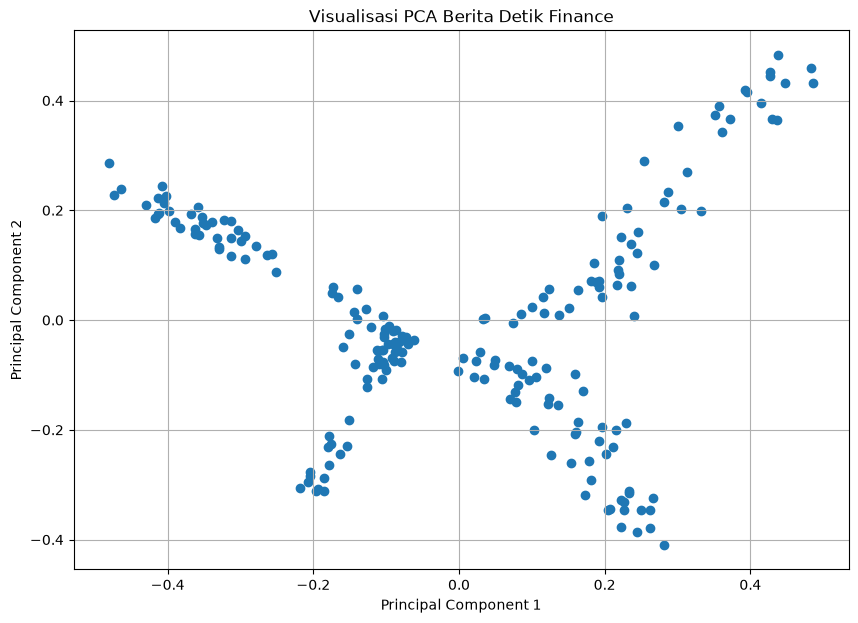

In [39]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Visualisasi PCA Berita Detik Finance")

plt.grid(True)

plt.show()

In [40]:
# Simpan hasil preprocessing Finance + Sport
df_scraping.to_csv(
    "hasil_preprocessing_detik_finance_sport.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Hasil preprocessing Finance + Sport berhasil disimpan."
)

print(
    f"Jumlah data: {len(df_scraping)} artikel"
)

Hasil preprocessing Finance + Sport berhasil disimpan.
Jumlah data: 205 artikel


In [41]:
# Simpan hasil PCA Finance + Sport
df_pca.to_csv(
    "hasil_pca_detik_finance_sport.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Hasil PCA Finance + Sport berhasil disimpan.")
print(f"Jumlah data: {len(df_pca)} artikel")

Hasil PCA Finance + Sport berhasil disimpan.
Jumlah data: 205 artikel


In [42]:
# Simpan hasil TF-IDF Finance + Sport
df_tfidf.to_csv(
    "hasil_tfidf_detik_finance_sport.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Hasil TF-IDF Finance + Sport berhasil disimpan.")
print(f"Jumlah data: {len(df_tfidf)} artikel")
print(f"Jumlah kolom TF-IDF: {len(df_tfidf.columns)}")

Hasil TF-IDF Finance + Sport berhasil disimpan.
Jumlah data: 205 artikel
Jumlah kolom TF-IDF: 4470


In [43]:
import pandas as pd
import json

# Baca hasil preprocessing Finance + Sport
df = pd.read_csv(
    "hasil_preprocessing_detik_finance_sport.csv"
)

# Konversi ke JSON
df.to_json(
    "hasil_preprocessing_detik_finance_sport.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("JSON berhasil dibuat!")
print("Jumlah data:", len(df))

JSON berhasil dibuat!
Jumlah data: 205


In [44]:
import pandas as pd

# Baca hasil TF-IDF Finance + Sport
df = pd.read_csv(
    "hasil_tfidf_detik_finance_sport.csv"
)

# Konversi ke JSON
df.to_json(
    "hasil_tfidf_detik_finance_sport.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("JSON berhasil dibuat!")
print("Jumlah data:", len(df))
print("Jumlah kolom:", len(df.columns))

JSON berhasil dibuat!
Jumlah data: 205
Jumlah kolom: 4470


In [45]:
import pandas as pd

# Baca hasil PCA Finance + Sport
df = pd.read_csv(
    "hasil_pca_detik_finance_sport.csv"
)

# Konversi ke JSON
df.to_json(
    "hasil_pca_detik_finance_sport.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("JSON berhasil dibuat!")
print("Jumlah data:", len(df))
print("Kolom:", df.columns.tolist())

JSON berhasil dibuat!
Jumlah data: 205
Kolom: ['PC1', 'PC2', 'kategori', 'judul', 'isi', 'url']


In [18]:
# ============================================================
# CELL 1 - INSTALL LIBRARY
# ============================================================

!pip install tensorflow scikit-learn pandas matplotlib seaborn

     -------------------------------------- 294.9/294.9 kB 2.6 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# ============================================================
# CELL 2 - IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

print("Semua library berhasil di-import!")
print("TensorFlow:", tf.__version__)

Semua library berhasil di-import!
TensorFlow: 2.21.0


In [6]:
# ============================================================
# CELL 2 - LOAD HASIL TF-IDF
# ============================================================

import pandas as pd

df_tfidf = pd.read_csv(
    "hasil_tfidf_detik_finance_sport.csv"
)

print("Ukuran dataset TF-IDF:")
print(df_tfidf.shape)

print("\nNama kolom:")
print(df_tfidf.columns.tolist())

print("\n5 data pertama:")
display(df_tfidf.head())

Ukuran dataset TF-IDF:
(205, 4470)

Nama kolom:
['aaplx', 'abadi', 'abai', 'abang', 'abankwah', 'abar', 'abdi', 'abdul', 'absen', 'ac', 'academy', 'acara', 'accident', 'account', 'acd', 'ace', 'aceh', 'acl', 'act', 'acu', 'ada', 'adakan', 'adams', 'adang', 'adaptasi', 'adaptif', 'adaptive', 'adcp', 'adhi', 'adi', 'adil', 'admin', 'administrasi', 'administratif', 'adopsi', 'adp', 'adr', 'adrianto', 'adrien', 'adu', 'advertisement', 'advisory', 'adzic', 'aee', 'aff', 'affengruber', 'aftech', 'against', 'agam', 'agency', 'agenda', 'ageng', 'agraria', 'agreement', 'agresif', 'agresivitas', 'agun', 'agung', 'agus', 'agustus', 'ahi', 'ahli', 'ahy', 'ai', 'air', 'aires', 'airnav', 'airport', 'aja', 'ajaib', 'ajak', 'ajang', 'ajar', 'aji', 'aju', 'akademi', 'akal', 'akan', 'akanji', 'akd', 'akhir', 'akibat', 'akn', 'akomodasi', 'akrab', 'akses', 'aksesibilitas', 'aksi', 'aktif', 'aktivitas', 'aktual', 'aku', 'akuisisi', 'akun', 'akuntabel', 'akuntabilitas', 'akurasi', 'akurat', 'alajbegovic', 

,aaplx,abadi,abai,abang,abankwah,abar,abdi,abdul,absen,ac,...,zhegrova,zhergova,zidane,zielinski,zielinsky,zinedine,zion,zirkzee,zona,zubimendi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# ============================================================
# CELL 3 - LOAD DATA HASIL PREPROCESSING
# ============================================================

df = pd.read_csv(
    "hasil_preprocessing_detik_finance_sport.csv"
)

print("=" * 60)
print("INFORMASI DATA")
print("=" * 60)

print("Ukuran data:", df.shape)

print("\nNama kolom:")
print(df.columns.tolist())

print("\nDistribusi kategori:")
print(
    df["kategori"].value_counts(dropna=False)
)

display(df.head())

INFORMASI DATA
Ukuran data: (205, 5)

Nama kolom:
['kategori', 'judul', 'url', 'isi', 'teks_preprocessing']

Distribusi kategori:
kategori
Sport      105
Finance    100
Name: count, dtype: int64


,kategori,judul,url,isi,teks_preprocessing
0,Finance,"Bitcoin Tembus US$ 87.000, Ini Sederet Pemicunya",https://finance.detik.com/fintech/d-8674812/bi...,Jakarta - Harga Bitcoin (BTC) sempat menembus ...,jakarta harga bitcoin btc tembus level tinggi ...
1,Finance,"Harga Bitcoin Terbang ke Rp 1,53 M, Tertinggi ...",https://finance.detik.com/fintech/d-8673320/ha...,Jakarta - Harga Bitcoin naik menembus level US...,jakarta harga bitcoin tembus level us rp milia...
2,Finance,Bitcoin Melesat Usai Pengumuman Suku Bunga AS,https://finance.detik.com/fintech/d-8667716/bi...,Jakarta - Harga Bitcoin (BTC) bergerak naik da...,jakarta harga bitcoin btc gerak kisar us rp mi...
3,Finance,"Investor Muda Dominasi Pasar Modal, Ajaib Kena...",https://finance.detik.com/fintech/d-8673492/in...,Jakarta - Ajaib memperkuat edukasi pasar modal...,jakarta ajaib kuat edukasi pasar modal hadir m...
4,Finance,"Harga Bitcoin Naik Jadi 1,35 Miliar Usai The F...",https://finance.detik.com/fintech/d-8666685/ha...,Jakarta - Harga Bitcoin menguat pada perdagang...,jakarta harga bitcoin kuat dagang kamis federa...


In [14]:
# ============================================================
# CELL 4 - PEMBERSIHAN DATA
# ============================================================

# Bersihkan kategori
df["kategori"] = (
    df["kategori"]
    .astype(str)
    .str.strip()
)

# Standarisasi nama kategori
df["kategori"] = (
    df["kategori"]
    .replace({
        "finance": "Finance",
        "FINANCE": "Finance",
        "sport": "Sport",
        "SPORT": "Sport"
    })
)

# Hanya gunakan Finance dan Sport
df = df[
    df["kategori"].isin(["Finance", "Sport"])
].copy()

# Hapus data yang tidak memiliki teks preprocessing
df = df.dropna(
    subset=["teks_preprocessing"]
)

# Pastikan teks berupa string
df["teks_preprocessing"] = (
    df["teks_preprocessing"]
    .astype(str)
)

print("=" * 60)
print("HASIL PEMBERSIHAN")
print("=" * 60)

print("Jumlah data:", len(df))

print("\nDistribusi kategori:")
print(
    df["kategori"].value_counts()
)

print("\nJumlah data kosong:")
print(
    df["teks_preprocessing"].isna().sum()
)

HASIL PEMBERSIHAN
Jumlah data: 205

Distribusi kategori:
kategori
Sport      105
Finance    100
Name: count, dtype: int64

Jumlah data kosong:
0


In [15]:
# ============================================================
# CELL 5 - MEMISAHKAN TEKS DAN LABEL
# ============================================================

teks = df["teks_preprocessing"]

label = df["kategori"]

# Encode:
# Finance = 0
# Sport   = 1

label_mapping = {
    "Finance": 0,
    "Sport": 1
}

y = label.map(label_mapping)

print("Mapping label:")
print(label_mapping)

print("\nDistribusi label:")
print(
    y.value_counts()
)

print("\nJumlah NaN pada label:", y.isna().sum())

Mapping label:
{'Finance': 0, 'Sport': 1}

Distribusi label:
kategori
1    105
0    100
Name: count, dtype: int64

Jumlah NaN pada label: 0


In [16]:
# ============================================================
# CELL 6 - TRAIN TEST SPLIT
# ============================================================

teks_train, teks_test, y_train, y_test = train_test_split(
    teks,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN TEST SPLIT")
print("=" * 60)

print("Jumlah data training :", len(teks_train))
print("Jumlah data testing  :", len(teks_test))

print("\nDistribusi training:")
print(y_train.value_counts())

print("\nDistribusi testing:")
print(y_test.value_counts())

TRAIN TEST SPLIT
Jumlah data training : 164
Jumlah data testing  : 41

Distribusi training:
kategori
1    84
0    80
Name: count, dtype: int64

Distribusi testing:
kategori
1    21
0    20
Name: count, dtype: int64


In [20]:
# ============================================================
# CELL 7 - TF-IDF
# ============================================================

vectorizer = TfidfVectorizer(
    max_features=5000
)

# Fit hanya menggunakan data training
X_train_tfidf = vectorizer.fit_transform(
    teks_train
)

# Data testing hanya transform
X_test_tfidf = vectorizer.transform(
    teks_test
)

print("=" * 60)
print("TF-IDF")
print("=" * 60)

print("Ukuran X_train:", X_train_tfidf.shape)
print("Ukuran X_test :", X_test_tfidf.shape)

print(
    "Jumlah fitur:",
    len(vectorizer.get_feature_names_out())
)

TF-IDF
Ukuran X_train: (164, 4098)
Ukuran X_test : (41, 4098)
Jumlah fitur: 4098


In [22]:
# ============================================================
# CELL 8 - SIMPAN HASIL TF-IDF (VERSI AMAN)
# ============================================================

fitur_tfidf = vectorizer.get_feature_names_out()

# Gabungkan data training dan testing
X_tfidf_all = np.vstack([
    X_train_tfidf.toarray(),
    X_test_tfidf.toarray()
])

# Buat DataFrame TF-IDF
df_tfidf_baru = pd.DataFrame(
    X_tfidf_all,
    columns=fitur_tfidf
)

# Ambil kategori sesuai urutan data
kategori_all = pd.concat([
    df.loc[teks_train.index, "kategori"],
    df.loc[teks_test.index, "kategori"]
]).values

# Kalau kolom kategori sudah ada, hapus dulu
if "kategori" in df_tfidf_baru.columns:
    df_tfidf_baru = df_tfidf_baru.drop(
        columns=["kategori"]
    )

# Tambahkan kategori
df_tfidf_baru.insert(
    0,
    "kategori",
    kategori_all
)

# Simpan
df_tfidf_baru.to_csv(
    "hasil_tfidf_detik_finance_sport.csv",
    index=False
)

print("=" * 60)
print("TF-IDF BERHASIL")
print("=" * 60)

print("Jumlah data :", len(df_tfidf_baru))
print("Jumlah fitur:", len(fitur_tfidf))

print("\nDistribusi kategori:")
print(
    df_tfidf_baru["kategori"].value_counts()
)

display(df_tfidf_baru.head())

TF-IDF BERHASIL
Jumlah data : 205
Jumlah fitur: 4098

Distribusi kategori:
kategori
Sport      105
Finance    100
Name: count, dtype: int64


,kategori,aaplx,abadi,abai,abankwah,abar,abdi,abdul,absen,ac,...,zeki,zerbi,zero,zhegrova,zhergova,zielinski,zielinsky,zirkzee,zona,zubimendi
0,Finance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,Finance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,Finance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
3,Sport,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.053244,0.0,0.0,0.0,0.053244,0.0,0.0,0.0,0.0,0.0
4,Finance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [23]:
# ============================================================
# CELL 9 - KONVERSI TF-IDF KE ARRAY
# ============================================================

X_train_no_pca = X_train_tfidf.toarray()
X_test_no_pca = X_test_tfidf.toarray()

y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()

print("X_train:", X_train_no_pca.shape)
print("X_test :", X_test_no_pca.shape)

print("y_train:", y_train_array.shape)
print("y_test :", y_test_array.shape)

X_train: (164, 4098)
X_test : (41, 4098)
y_train: (164,)
y_test : (41,)


In [24]:
# ============================================================
# CELL 10 - PCA 95% VARIANCE
# ============================================================

pca = PCA(
    n_components=0.95,
    random_state=42
)

# PCA hanya fit pada data training
X_train_pca = pca.fit_transform(
    X_train_no_pca
)

# Testing menggunakan PCA yang sama
X_test_pca = pca.transform(
    X_test_no_pca
)

print("=" * 60)
print("PCA 95%")
print("=" * 60)

print("Fitur sebelum PCA :", X_train_no_pca.shape[1])
print("Fitur setelah PCA :", X_train_pca.shape[1])

print(
    "Variance yang dipertahankan:",
    pca.explained_variance_ratio_.sum()
)

PCA 95%
Fitur sebelum PCA : 4098
Fitur setelah PCA : 129
Variance yang dipertahankan: 0.9508169595054428


In [25]:
# ============================================================
# CELL 11 - FUNGSI MEMBUAT MODEL CNN
# ============================================================

def buat_model_cnn(jumlah_fitur):

    model = Sequential([
        
        Conv1D(
            filters=64,
            kernel_size=3,
            activation="relu",
            input_shape=(jumlah_fitur, 1)
        ),

        MaxPooling1D(
            pool_size=2
        ),

        Conv1D(
            filters=128,
            kernel_size=3,
            activation="relu"
        ),

        MaxPooling1D(
            pool_size=2
        ),

        Flatten(),

        Dense(
            128,
            activation="relu"
        ),

        Dropout(0.5),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [26]:
# ============================================================
# CELL 12 - RESHAPE DATA UNTUK CNN
# ============================================================

# CNN membutuhkan bentuk:
# jumlah_data x jumlah_fitur x 1

X_train_cnn_no_pca = X_train_no_pca.reshape(
    X_train_no_pca.shape[0],
    X_train_no_pca.shape[1],
    1
)

X_test_cnn_no_pca = X_test_no_pca.reshape(
    X_test_no_pca.shape[0],
    X_test_no_pca.shape[1],
    1
)

X_train_cnn_pca = X_train_pca.reshape(
    X_train_pca.shape[0],
    X_train_pca.shape[1],
    1
)

X_test_cnn_pca = X_test_pca.reshape(
    X_test_pca.shape[0],
    X_test_pca.shape[1],
    1
)

print("CNN tanpa PCA:")
print("Train:", X_train_cnn_no_pca.shape)
print("Test :", X_test_cnn_no_pca.shape)

print("\nCNN dengan PCA:")
print("Train:", X_train_cnn_pca.shape)
print("Test :", X_test_cnn_pca.shape)

CNN tanpa PCA:
Train: (164, 4098, 1)
Test : (41, 4098, 1)

CNN dengan PCA:
Train: (164, 129, 1)
Test : (41, 129, 1)


In [27]:
# ============================================================
# CELL 13 - CNN + TF-IDF TANPA PCA
# ============================================================

cnn_no_pca = buat_model_cnn(
    X_train_no_pca.shape[1]
)

cnn_no_pca.summary()

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

history_cnn_no_pca = cnn_no_pca.fit(
    X_train_cnn_no_pca,
    y_train_array,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

waktu_cnn_no_pca = time.time() - start_time

print(
    "\nWaktu training CNN tanpa PCA:",
    round(waktu_cnn_no_pca, 2),
    "detik"
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4096, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2048, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2046, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1023, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 130944)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,760,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,786,049 (64.03 MB)

 Trainable params: 16,786,049 (64.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 374ms/step - accuracy: 0.7863 - loss: 0.5228 - val_accuracy: 1.0000 - val_loss: 0.2300
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - accuracy: 1.0000 - loss: 0.0928 - val_accuracy: 1.0000 - val_loss: 0.0334
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 340ms/step - accuracy: 1.0000 - loss: 0.0126 - val_accuracy: 1.0000 - val_loss: 0.0082
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 313ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 322ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 320ms/step - accuracy: 1.0000 - loss: 3.6355e-04 - val_accuracy: 1.0000 - val_loss: 8.7782e-04
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 323ms/step - accuracy: 1.0000 - loss: 2.7871e-04 - val_accuracy: 1.0000 - val_loss: 4.7998e-04
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step - accuracy: 1.0000 - loss: 5.0808e-05 - val_accuracy

In [28]:
# ============================================================
# CELL 14 - EVALUASI CNN TANPA PCA
# ============================================================

pred_prob_cnn_no_pca = cnn_no_pca.predict(
    X_test_cnn_no_pca
)

pred_cnn_no_pca = (
    pred_prob_cnn_no_pca >= 0.5
).astype(int).ravel()

accuracy_cnn_no_pca = accuracy_score(
    y_test_array,
    pred_cnn_no_pca
)

precision_cnn_no_pca = precision_score(
    y_test_array,
    pred_cnn_no_pca,
    zero_division=0
)

recall_cnn_no_pca = recall_score(
    y_test_array,
    pred_cnn_no_pca,
    zero_division=0
)

f1_cnn_no_pca = f1_score(
    y_test_array,
    pred_cnn_no_pca,
    zero_division=0
)

print("=" * 60)
print("HASIL CNN TANPA PCA")
print("=" * 60)

print("Accuracy :", round(accuracy_cnn_no_pca, 4))
print("Precision:", round(precision_cnn_no_pca, 4))
print("Recall   :", round(recall_cnn_no_pca, 4))
print("F1-Score :", round(f1_cnn_no_pca, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test_array,
        pred_cnn_no_pca,
        target_names=["Finance", "Sport"],
        zero_division=0
    )
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step
HASIL CNN TANPA PCA
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0

Classification Report:
              precision    recall  f1-score   support

     Finance       1.00      1.00      1.00        20
       Sport       1.00      1.00      1.00        21

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



In [29]:
# ============================================================
# CELL 15 - CNN + TF-IDF + PCA
# ============================================================

cnn_pca = buat_model_cnn(
    X_train_pca.shape[1]
)

cnn_pca.summary()

start_time = time.time()

history_cnn_pca = cnn_pca.fit(
    X_train_cnn_pca,
    y_train_array,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

waktu_cnn_pca = time.time() - start_time

print(
    "\nWaktu training CNN dengan PCA:",
    round(waktu_cnn_pca, 2),
    "detik"
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 127, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 516,737 (1.97 MB)

 Trainable params: 516,737 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.6260 - loss: 0.6790 - val_accuracy: 0.5758 - val_loss: 0.6650
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7634 - loss: 0.6115 - val_accuracy: 0.8182 - val_loss: 0.5577
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8473 - loss: 0.5205 - val_accuracy: 0.8485 - val_loss: 0.4565
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8550 - loss: 0.4355 - val_accuracy: 0.8182 - val_loss: 0.3945
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8855 - loss: 0.3327 - val_accuracy: 0.9091 - val_loss: 0.2616
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9466 - loss: 0.2256 - val_accuracy: 0.9394 - val_loss: 0.2161
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9695 - loss: 0.1538 - val_accuracy: 1.0000 - val_loss: 0.0993
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9924 - loss: 0.0808 - val_accuracy: 1.0000 - val_loss: 0.0661


In [30]:
# ============================================================
# CELL 16 - EVALUASI CNN DENGAN PCA
# ============================================================

pred_prob_cnn_pca = cnn_pca.predict(
    X_test_cnn_pca
)

pred_cnn_pca = (
    pred_prob_cnn_pca >= 0.5
).astype(int).ravel()

accuracy_cnn_pca = accuracy_score(
    y_test_array,
    pred_cnn_pca
)

precision_cnn_pca = precision_score(
    y_test_array,
    pred_cnn_pca,
    zero_division=0
)

recall_cnn_pca = recall_score(
    y_test_array,
    pred_cnn_pca,
    zero_division=0
)

f1_cnn_pca = f1_score(
    y_test_array,
    pred_cnn_pca,
    zero_division=0
)

print("=" * 60)
print("HASIL CNN DENGAN PCA")
print("=" * 60)

print("Accuracy :", round(accuracy_cnn_pca, 4))
print("Precision:", round(precision_cnn_pca, 4))
print("Recall   :", round(recall_cnn_pca, 4))
print("F1-Score :", round(f1_cnn_pca, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test_array,
        pred_cnn_pca,
        target_names=["Finance", "Sport"],
        zero_division=0
    )
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
HASIL CNN DENGAN PCA
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0

Classification Report:
              precision    recall  f1-score   support

     Finance       1.00      1.00      1.00        20
       Sport       1.00      1.00      1.00        21

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



In [31]:
# ============================================================
# CELL 17 - RANDOM FOREST + TF-IDF TANPA PCA
# ============================================================

rf_no_pca = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_no_pca.fit(
    X_train_no_pca,
    y_train_array
)

waktu_rf_no_pca = time.time() - start_time

pred_rf_no_pca = rf_no_pca.predict(
    X_test_no_pca
)

accuracy_rf_no_pca = accuracy_score(
    y_test_array,
    pred_rf_no_pca
)

precision_rf_no_pca = precision_score(
    y_test_array,
    pred_rf_no_pca,
    zero_division=0
)

recall_rf_no_pca = recall_score(
    y_test_array,
    pred_rf_no_pca,
    zero_division=0
)

f1_rf_no_pca = f1_score(
    y_test_array,
    pred_rf_no_pca,
    zero_division=0
)

print("=" * 60)
print("RANDOM FOREST TANPA PCA")
print("=" * 60)

print("Accuracy :", round(accuracy_rf_no_pca, 4))
print("Precision:", round(precision_rf_no_pca, 4))
print("Recall   :", round(recall_rf_no_pca, 4))
print("F1-Score :", round(f1_rf_no_pca, 4))
print("Waktu    :", round(waktu_rf_no_pca, 2), "detik")

RANDOM FOREST TANPA PCA
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0
Waktu    : 1.46 detik


In [32]:
# ============================================================
# CELL 18 - RANDOM FOREST + TF-IDF + PCA
# ============================================================

rf_pca = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_pca.fit(
    X_train_pca,
    y_train_array
)

waktu_rf_pca = time.time() - start_time

pred_rf_pca = rf_pca.predict(
    X_test_pca
)

accuracy_rf_pca = accuracy_score(
    y_test_array,
    pred_rf_pca
)

precision_rf_pca = precision_score(
    y_test_array,
    pred_rf_pca,
    zero_division=0
)

recall_rf_pca = recall_score(
    y_test_array,
    pred_rf_pca,
    zero_division=0
)

f1_rf_pca = f1_score(
    y_test_array,
    pred_rf_pca,
    zero_division=0
)

print("=" * 60)
print("RANDOM FOREST DENGAN PCA")
print("=" * 60)

print("Accuracy :", round(accuracy_rf_pca, 4))
print("Precision:", round(precision_rf_pca, 4))
print("Recall   :", round(recall_rf_pca, 4))
print("F1-Score :", round(f1_rf_pca, 4))
print("Waktu    :", round(waktu_rf_pca, 2), "detik")

RANDOM FOREST DENGAN PCA
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0
Waktu    : 1.58 detik


In [33]:
# ============================================================
# CELL 19 - PERBANDINGAN SEMUA MODEL
# ============================================================

hasil_perbandingan = pd.DataFrame({

    "Model": [
        "CNN",
        "CNN",
        "Random Forest",
        "Random Forest"
    ],

    "PCA": [
        "Tanpa PCA",
        "Dengan PCA",
        "Tanpa PCA",
        "Dengan PCA"
    ],

    "Fitur": [
        X_train_no_pca.shape[1],
        X_train_pca.shape[1],
        X_train_no_pca.shape[1],
        X_train_pca.shape[1]
    ],

    "Accuracy": [
        accuracy_cnn_no_pca,
        accuracy_cnn_pca,
        accuracy_rf_no_pca,
        accuracy_rf_pca
    ],

    "Precision": [
        precision_cnn_no_pca,
        precision_cnn_pca,
        precision_rf_no_pca,
        precision_rf_pca
    ],

    "Recall": [
        recall_cnn_no_pca,
        recall_cnn_pca,
        recall_rf_no_pca,
        recall_rf_pca
    ],

    "F1-Score": [
        f1_cnn_no_pca,
        f1_cnn_pca,
        f1_rf_no_pca,
        f1_rf_pca
    ],

    "Waktu Training (detik)": [
        waktu_cnn_no_pca,
        waktu_cnn_pca,
        waktu_rf_no_pca,
        waktu_rf_pca
    ]
})

display(
    hasil_perbandingan.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Waktu Training (detik)": "{:.2f}"
    })
)

,Model,PCA,Fitur,Accuracy,Precision,Recall,F1-Score,Waktu Training (detik)
0,CNN,Tanpa PCA,4098,1.0000,1.0000,1.0000,1.0000,124.69
1,CNN,Dengan PCA,129,1.0000,1.0000,1.0000,1.0000,16.11
2,Random Forest,Tanpa PCA,4098,1.0000,1.0000,1.0000,1.0000,1.46
3,Random Forest,Dengan PCA,129,1.0000,1.0000,1.0000,1.0000,1.58


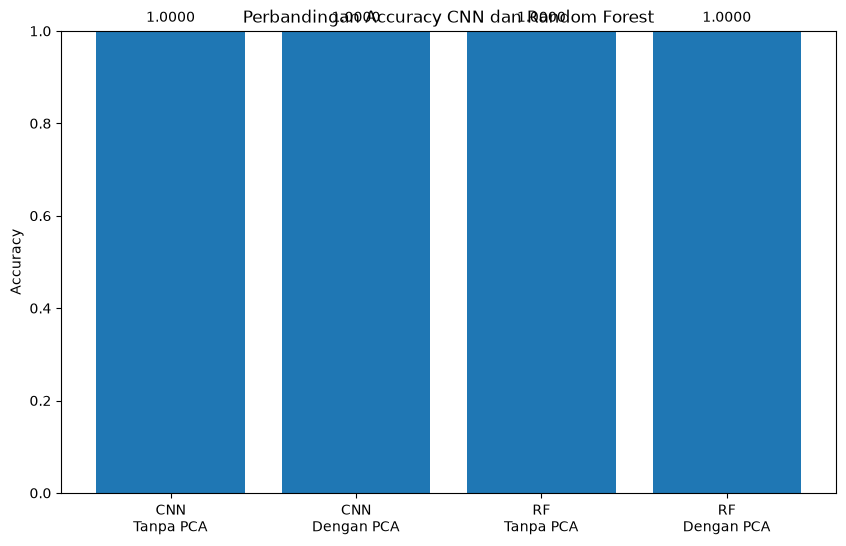

In [34]:
# ============================================================
# CELL 20 - GRAFIK ACCURACY
# ============================================================

label_model = [
    "CNN\nTanpa PCA",
    "CNN\nDengan PCA",
    "RF\nTanpa PCA",
    "RF\nDengan PCA"
]

nilai_accuracy = [
    accuracy_cnn_no_pca,
    accuracy_cnn_pca,
    accuracy_rf_no_pca,
    accuracy_rf_pca
]

plt.figure(figsize=(10, 6))

plt.bar(
    label_model,
    nilai_accuracy
)

plt.ylim(0, 1)

plt.ylabel("Accuracy")
plt.title("Perbandingan Accuracy CNN dan Random Forest")

for i, nilai in enumerate(nilai_accuracy):
    plt.text(
        i,
        nilai + 0.02,
        f"{nilai:.4f}",
        ha="center"
    )

plt.show()

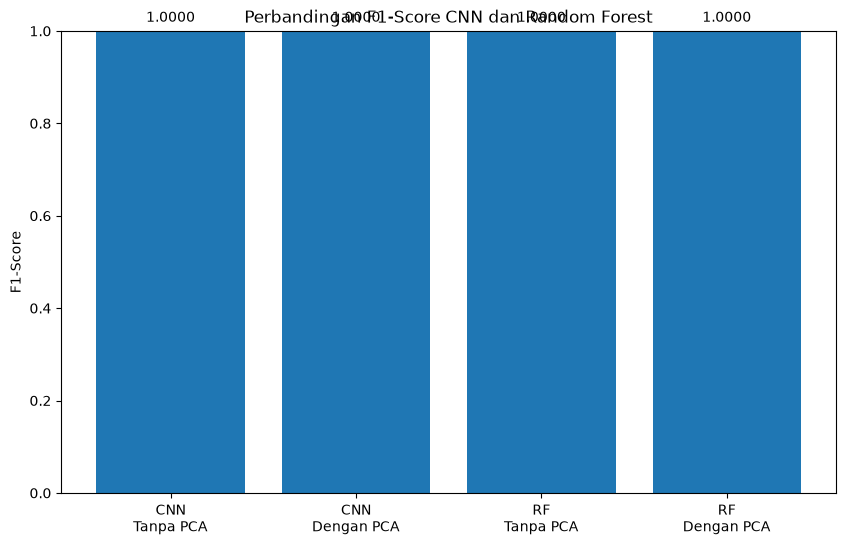

In [35]:
# ============================================================
# CELL 21 - GRAFIK F1-SCORE
# ============================================================

nilai_f1 = [
    f1_cnn_no_pca,
    f1_cnn_pca,
    f1_rf_no_pca,
    f1_rf_pca
]

plt.figure(figsize=(10, 6))

plt.bar(
    label_model,
    nilai_f1
)

plt.ylim(0, 1)

plt.ylabel("F1-Score")
plt.title("Perbandingan F1-Score CNN dan Random Forest")

for i, nilai in enumerate(nilai_f1):
    plt.text(
        i,
        nilai + 0.02,
        f"{nilai:.4f}",
        ha="center"
    )

plt.show()

In [36]:
# ============================================================
# CELL 22 - PERBANDINGAN JUMLAH FITUR
# ============================================================

fitur_awal = X_train_no_pca.shape[1]
fitur_pca = X_train_pca.shape[1]

pengurangan = (
    (fitur_awal - fitur_pca)
    / fitur_awal
) * 100

print("=" * 60)
print("PERBANDINGAN DIMENSI")
print("=" * 60)

print("Fitur sebelum PCA :", fitur_awal)
print("Fitur setelah PCA :", fitur_pca)

print(
    "Pengurangan fitur :",
    round(pengurangan, 2),
    "%"
)

PERBANDINGAN DIMENSI
Fitur sebelum PCA : 4098
Fitur setelah PCA : 129
Pengurangan fitur : 96.85 %


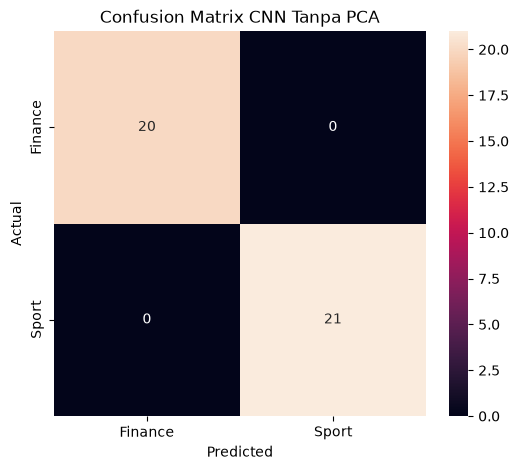

In [37]:
# ============================================================
# CELL 23 - CONFUSION MATRIX CNN
# ============================================================

cm_cnn = confusion_matrix(
    y_test_array,
    pred_cnn_no_pca
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    xticklabels=["Finance", "Sport"],
    yticklabels=["Finance", "Sport"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix CNN Tanpa PCA")

plt.show()

In [38]:
# ============================================================
# CELL 25 - SIMPAN HASIL
# ============================================================

hasil_perbandingan.to_csv(
    "hasil_perbandingan_model.csv",
    index=False
)

print(
    "Hasil perbandingan berhasil disimpan:"
)

print(
    "hasil_perbandingan_model.csv"
)

Hasil perbandingan berhasil disimpan:
hasil_perbandingan_model.csv


In [39]:
# ============================================================
# CELL 26 - SIMPAN HASIL PERBANDINGAN MODEL KE JSON
# ============================================================

hasil_perbandingan.to_json(
    "hasil_perbandingan_model.json",
    orient="records",
    indent=4
)

print("=" * 60)
print("HASIL MODEL BERHASIL DISIMPAN KE JSON")
print("=" * 60)

print(
    "File: hasil_perbandingan_model.json"
)

display(hasil_perbandingan)

HASIL MODEL BERHASIL DISIMPAN KE JSON
File: hasil_perbandingan_model.json


,Model,PCA,Fitur,Accuracy,Precision,Recall,F1-Score,Waktu Training (detik)
0,CNN,Tanpa PCA,4098,1.0,1.0,1.0,1.0,124.692355
1,CNN,Dengan PCA,129,1.0,1.0,1.0,1.0,16.113757
2,Random Forest,Tanpa PCA,4098,1.0,1.0,1.0,1.0,1.461512
3,Random Forest,Dengan PCA,129,1.0,1.0,1.0,1.0,1.581173
